# NISAR DEM: Cloud-Optimized Access and Visualization

Authors: Harshini Girish(UAH), Alex Mandel(Development Seed)

Date:Febuary 12, 2026

Description:This notebook shows how to avoid full downloads by querying CMR for NISAR DEM granules (collection C3803703055-ASF), extracting each granule’s bounding-box footprint + data link, then using Earthdata login + temporary S3 credentials to open the DEM directly from S3 via /vsis3/ and stream only a small window of pixels with Rasterio/GDAL, finally visualizing the footprints and the streamed preview on an interactive Folium map.

## Run This Notebook
To access and run this tutorial within MAAP's Algorithm Development Environment (ADE), please refer to the ["Getting started with the MAAP"](https://docs.maap-project.org/en/latest/getting_started/getting_started.html) section of our documentation.

Disclaimer: it is highly recommended to run a tutorial within MAAP's ADE, which already includes packages specific to MAAP, such as maap-py. Running the tutorial outside of the MAAP ADE may lead to errors.

## Additional Resources
- [OPERA Surface Displacement](https://docs.maap-project.org/en/latest/science/OPERA/OPERA_Surface_Displacement.html)
- [NISAR Access](https://docs.maap-project.org/en/latest/science/NISAR/NISAR_access.html)
- [Searching NISAR–BIOMASS Overlapping Data](https://docs.maap-project.org/en/develop/technical_tutorials/search/searching_NISAR_BIOMASS_overlapping_data.html)


## About the Dataset

The CMR collection C3803703055-ASF is the ASF-hosted NISAR DEM distribution, which provides the Modified Copernicus Digital Elevation Model products used by the NISAR mission. It contains global elevation data packaged for cloud delivery (including DEM tiles and supporting index/metadata files) and is distributed through the NISAR EarthdataCloud endpoints. The collection supports both standard HTTP access and direct in-region S3 access (via an S3 bucket/prefix and a temporary credentials endpoint), which makes it well-suited for “streaming” workflows where you read only the needed byte ranges/windows from remote GeoTIFF/COG tiles instead of downloading full rasters.

## Import and Install Packages

In [1]:
import os
import io
import base64
from urllib.parse import urlparse

import requests
import numpy as np

import earthaccess
import rasterio as rio
from rasterio.windows import from_bounds

import geopandas as gpd
from shapely.geometry import box, mapping

import folium
from PIL import Image

## Input
Define an Area of Interest (AOI)

In [6]:
# AOI inside the chosen tile (S90_W180)  
target_aoi_bounds = (-179.8, -89.8, -179.2, -89.2)


## Searching the Data 

This cell queries NASA’s Common Metadata Repository  using the `granules.umm_json` endpoint to retrieve granule metadata for a specific collection, `fetch_granules()` sends an HTTP request (waiting up to `timeout=60` seconds) and returns the list of granules under `["items"]`. For each granule’s UMM metadata, `bounding_boxes()` extracts any `BoundingRectangles` and converts them into simple  tuples that can later be turned into footprint polygons for mapping/intersection. `data_link()` then looks through `RelatedUrls` and picks the best file access link—preferring `s3://` direct access** for streaming via `/vsis3`, and otherwise falling back to the first HTTP link that looks like a raster/index file. Finally, the last lines run the query for the NISAR DEM collection and print how many granules were returned on that page.

In [3]:
CMR_URL = "https://cmr.earthdata.nasa.gov/search/granules.umm_json"

def fetch_granules(concept_id, n=200, page=1):
    r = requests.get(
        CMR_URL,
        params={"collection_concept_id": concept_id, "page_size": n, "page_num": page},
        timeout=60,
    )
    r.raise_for_status()
    return r.json()["items"]

def bounding_boxes(umm):
    rects = (
        umm.get("SpatialExtent", {})
           .get("HorizontalSpatialDomain", {})
           .get("Geometry", {})
           .get("BoundingRectangles", [])
    )
    return [(r["WestBoundingCoordinate"], r["SouthBoundingCoordinate"],
             r["EastBoundingCoordinate"], r["NorthBoundingCoordinate"]) for r in rects]

def data_link(umm):
    # Prefer direct s3:// access; otherwise first http(s) .tif/.tiff/.vrt link
    urls = [ru.get("URL", "") for ru in umm.get("RelatedUrls", [])]
    for u in urls:
        if u.startswith("s3://"):
            return u
    for u in urls:
        if u.lower().startswith("http") and u.lower().endswith((".tif", ".tiff", ".vrt")):
            return u
    return None

concept_id = "C3803703055-ASF"
items = fetch_granules(concept_id, n=200, page=1)
print("Granules fetched:", len(items))


Granules fetched: 200


### Build Footprints GeoDataFrame

This cell builds a GeoDataFrame of granule footprints for the CMR collection `C3803703055-ASF`. It loops through each returned granule (`items`), pulls out the UMM metadata and the granule concept-id, then uses `bounding_boxes(umm)` to extract one or more bounding rectangles for that granule. For every bounding box, it appends a row containing the granule id, a readable title (`GranuleUR`), a preferred access link, and a Shapely polygon created from the bounds (`box(*b)`). Finally, it converts the list of rows into a GeoPandas `GeoDataFrame` with the geometry column set to `"geometry"` and CRS set to `EPSG:4326`, so you can map the footprints, filter by AOI overlap, and later use `data_url` to stream the selected raster without downloading the full file.


In [4]:
rows = []
for it in items:
    umm = it["umm"]
    gran_id = it["meta"]["concept-id"]
    title = umm.get("GranuleUR", gran_id)
    url = data_link(umm)

    for b in bounding_boxes(umm):
        rows.append({"concept_id": gran_id, "title": title, "data_url": url, "geometry": box(*b)})

gdf = gpd.GeoDataFrame(rows, geometry="geometry", crs="EPSG:4326")
print("Footprints:", len(gdf))
gdf.head()


Footprints: 200


,concept_id,title,data_url,geometry
0,G3964549387-ASF,v1-2-EPSG4326-S90-S90_W180-DEM_S90_00_W180_00_...,s3://sds-n-cumulus-prod-nisar-products/DEM/v1....,"POLYGON ((-179 -90, -179 -89, -180 -89, -180 -..."
1,G3964549482-ASF,v1-2-EPSG4326-S90-S90_W180-DEM_S90_00_W179_00_...,s3://sds-n-cumulus-prod-nisar-products/DEM/v1....,"POLYGON ((-178 -90, -178 -89, -179 -89, -179 -..."
2,G3964549304-ASF,v1-2-EPSG4326-S90-S90_W180-DEM_S90_00_W178_00_...,s3://sds-n-cumulus-prod-nisar-products/DEM/v1....,"POLYGON ((-177 -90, -177 -89, -178 -89, -178 -..."
3,G3964549526-ASF,v1-2-EPSG4326-S90-S90_W180-DEM_S90_00_W177_00_...,s3://sds-n-cumulus-prod-nisar-products/DEM/v1....,"POLYGON ((-176 -90, -176 -89, -177 -89, -177 -..."
4,G3964549467-ASF,v1-2-EPSG4326-S90-S90_W180-DEM_S90_00_W176_00_...,s3://sds-n-cumulus-prod-nisar-products/DEM/v1....,"POLYGON ((-175 -90, -175 -89, -176 -89, -176 -..."


### Interactive map 
This cell builds an interactive Folium map centered on your AOI (`target_aoi_bounds`). It first computes the AOI center  and initializes a basemap. Then it loops through each row of `gdf` (your granule footprints GeoDataFrame) and adds the footprint geometry as a `GeoJson` layer styled in green, with a tooltip showing the granule `title`. After that, it adds the AOI itself as a red outline by converting the AOI bounds into a Shapely `box()` polygon and passing it through `mapping()` so Folium can render it. Finally, `LayerControl()` is added so you can toggle layers, and the last line outputs `m` to display the map.


In [7]:
minx, miny, maxx, maxy = target_aoi_bounds
m = folium.Map(location=[(miny + maxy) / 2, (minx + maxx) / 2], zoom_start=6, tiles="OpenStreetMap")

for _, r in gdf.iterrows():
    folium.GeoJson(
        r.geometry,
        style_function=lambda _: {"color": "green", "weight": 2, "fillOpacity": 0.05},
        tooltip=r["title"],
    ).add_to(m)

folium.GeoJson(
    mapping(box(*target_aoi_bounds)),
    style_function=lambda _: {"color": "red", "weight": 3, "fillOpacity": 0.0},
    name="AOI",
).add_to(m)

folium.LayerControl().add_to(m)
m


## Cloud Optimized Remote Access 

### Set up Access
This cell logs you into NASA Earthdata (via `earthaccess`) and then calls the NISAR EarthdataCloud S3 credentials endpoint to obtain temporary AWS credentials (access key, secret key, session token). Those credentials are placed into environment variables so GDAL/Rasterio can authenticate when reading files directly from the NISAR S3 bucket using `/vsis3/...`. This is what makes “remote/streamed” reads work without downloading the full GeoTIFF locally. (`timeout=60` just means the request will wait up to 60 seconds before failing.)



In [15]:
earthaccess.login()
sess = earthaccess.get_requests_https_session()

resp = sess.get("https://nisar.asf.earthdatacloud.nasa.gov/s3credentials", timeout=60)
resp.raise_for_status()
creds = resp.json()


os.environ["AWS_ACCESS_KEY_ID"]     = creds["accessKeyId"]
os.environ["AWS_SECRET_ACCESS_KEY"] = creds["secretAccessKey"]
os.environ["AWS_SESSION_TOKEN"]     = creds["sessionToken"]
os.environ["AWS_DEFAULT_REGION"]    = "us-west-2"



### Streaming Preview 

This cell defines the smallest set of helpers needed to (a) convert an `s3://...` URL into a GDAL `/vsis3/...` path, (b) set a couple of GDAL options to reduce slow directory listing behavior, and (c) read only a small window from the middle of the raster (e.g., 15% of the width/height). It then turns that window into a transparent PNG (NoData masked out) and computes the exact geographic bounds of the streamed window using the window’s transform. The output is a PNG data URL plus `[south, west]` and `[north, east]` bounds that Folium can use to align an overlay correctly on a web map.


In [17]:
#Minimal converter (only S3 direct access)
def s3_to_vsis3(s3_url: str) -> str:
    return "/vsis3/" + s3_url[len("s3://"):]


gdal_opts = {
    "GDAL_DISABLE_READDIR_ON_OPEN": "EMPTY_DIR",
    "AWS_REGION": "us-west-2",
}

# Helper: pick a small center window + turn it into a PNG overlay
def stream_center_preview_as_png(src, frac=0.15):
    left, bottom, right, top = src.bounds
    cx, cy = (left + right) / 2, (bottom + top) / 2
    w, h = (right - left) * frac, (top - bottom) * frac
    preview_bounds = (cx - w/2, cy - h/2, cx + w/2, cy + h/2)

    win = rio.windows.from_bounds(*preview_bounds, transform=src.transform)
    arr = src.read(1, window=win, masked=True)

    vals = arr.compressed()
    if vals.size == 0:
        return None, None  # empty window

    vmin, vmax = np.percentile(vals, [2, 98])
    img = np.clip((arr - vmin) / (vmax - vmin + 1e-9), 0, 1)
    img = (img * 255).astype("uint8")

    alpha = np.where(np.ma.getmaskarray(arr), 0, 220).astype("uint8")
    rgba = np.dstack([img, img, img, alpha])

    buf = io.BytesIO()
    Image.fromarray(rgba, mode="RGBA").save(buf, format="PNG")
    data_url = "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode("utf-8")

# compute exact lat/lon bounds of the streamed window for proper alignment
    t = src.window_transform(win)
    h_px, w_px = arr.shape
    win_left, win_top = t.c, t.f
    win_right = win_left + t.a * w_px
    win_bottom = win_top + t.e * h_px  

    return data_url, [[win_bottom, win_left], [win_top, win_right]]


#run: choose first granule and stream it 

chosen = gdf.iloc[0]  # first tile
print("Chosen:", chosen["title"])
print("Data URL:", chosen["data_url"])

vsis3_path = s3_to_vsis3(chosen["data_url"])

with rio.Env(**gdal_opts):
    with rio.open(vsis3_path) as src:
        overlay_png, overlay_bounds = stream_center_preview_as_png(src, frac=0.15)



Chosen: v1-2-EPSG4326-S90-S90_W180-DEM_S90_00_W180_00_C01-tif
Data URL: s3://sds-n-cumulus-prod-nisar-products/DEM/v1.2/EPSG4326/S90/S90_W180/DEM_S90_00_W180_00_C01.tif


### Interactive map 

This cell builds a Folium map and centers it on the streamed window if it exists (otherwise it falls back to the chosen tile’s footprint center). It then draws: (1) all available granule footprints in green for context, (2) the selected granule footprint in blue so you can see which tile you streamed from, and (3) the streamed PNG preview as an `ImageOverlay` positioned using the exact `[south, west]` / `[north, east]` bounds computed earlier. Finally, it adds a layer control so you can toggle the overlay and footprint layers on/off and visually confirm the streamed raster window is aligned on the basemap.



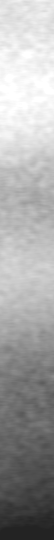

In [18]:
# --- map ---
# center map on streamed window (or on chosen footprint center if window empty)
if overlay_bounds:
    (south, west), (north, east) = overlay_bounds
    center = [(south + north) / 2, (west + east) / 2]
else:
    # fallback: center on chosen footprint
    minx, miny, maxx, maxy = chosen.geometry.bounds
    center = [(miny + maxy) / 2, (minx + maxx) / 2]

m = folium.Map(location=center, zoom_start=6, tiles="OpenStreetMap")

# footprints 
for _, r in gdf.iterrows():
    folium.GeoJson(
        r.geometry,
        style_function=lambda _: {"color": "green", "weight": 2, "fillOpacity": 0.05},
        tooltip=r["title"],
    ).add_to(m)

# chosen footprint
folium.GeoJson(
    chosen.geometry,
    style_function=lambda _: {"color": "blue", "weight": 3, "fillOpacity": 0},
    tooltip=f"CHOSEN: {chosen['title']}",
    name="Chosen tile",
).add_to(m)

# streamed preview overlay
if overlay_png is None:
    print("Preview window is empty (all NoData). Pick a different granule.")
else:
    folium.raster_layers.ImageOverlay(
        image=overlay_png,
        bounds=overlay_bounds,
        opacity=0.75,
        name="Streamed DEM preview",
    ).add_to(m)

folium.LayerControl().add_to(m)
m
